In [87]:
import numpy as np
import cv2
from PIL import Image
import glob
import numpy as np
import tqdm
from skimage.metrics import structural_similarity as ssim
from skimage.io import imread
from skimage.color import rgb2gray
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import defaultdict

gains = defaultdict(list)

total_ssim = np.zeros((len(images), len(images)))

for index in range(4):
    paths = glob.glob(rf"E:\MSImaging-data\_msi_visual\Benchmarking\mouse_brain_comprehensive_benchmark_large\{index}_*.png")
    paths = [p for p in paths if "eq" not in p]
    paths = sorted(paths)
    images = [np.array(Image.open(p)) for p in paths]

    # Compute SSIM pairwise matrix
    ssim_matrix = np.zeros((len(images), len(images)))

    
    for i, img1 in enumerate(images):
        for j, img2 in enumerate(images):
            # if j <= i:
            #     continue
            new_method = False
            for name in ["UMAP1", "UMAP2", "SaliencyOptimization", "SpearmanOptimization", "TOP3", "PercentileRatio"]:
                if name in paths[j]:
                    new_method = True
            if new_method:
               continue
            #print(paths[i], paths[j])
            similarity = ssim(img1, img2,  channel_axis = 2)
            ssim_matrix[i, j] = similarity
            ssim_matrix[j, i] = similarity  # Symmetric matrix

        # Convert SSIM to a "dissimilarity" matrix (distance = 1 - similarity)
        dissimilarity_matrix = 1 - ssim_matrix
        total_ssim = total_ssim + ssim_matrix
        # Compute information gain for each image
        info_gain = [1 - max(ssim_matrix[i, :]) for i in range(len(images))]

        # Rank images by added benefit
        
        image_paths = [p.split("\\")[-1].split('.')[0].split('_')[1] for p in paths]
        for image_index, p in enumerate(image_paths):
            gains[p].append(info_gain[image_index])

for path in gains:
    gains[path] = np.mean(gains[path])

total_ssim = total_ssim / 4

In [88]:
keys = list(gains.keys())
keys = sorted(keys, key=lambda k: -gains[k])
for k in keys:
    print(k, gains[k])

UMAP2 0.9806654131354932
UMAP1 0.9445019631335053
TOP3 0.8921249101952452
SpearmanOptimization 0.8257454447614412
PercentileRatio 0.8167077936443226
SaliencyOptimization 0.8092271784990616
TSNE3D 0.47216860952359424
Trimap3D 0.4626604412799414
PHATE3D 0.2549439998796759
PCA3D 0.14985724838787493
PACMAC3D 0.14979723829625224
NMF3D 0.10117391453692563
Isomap3D 0.046124050852783184
FastICA3D 0.0


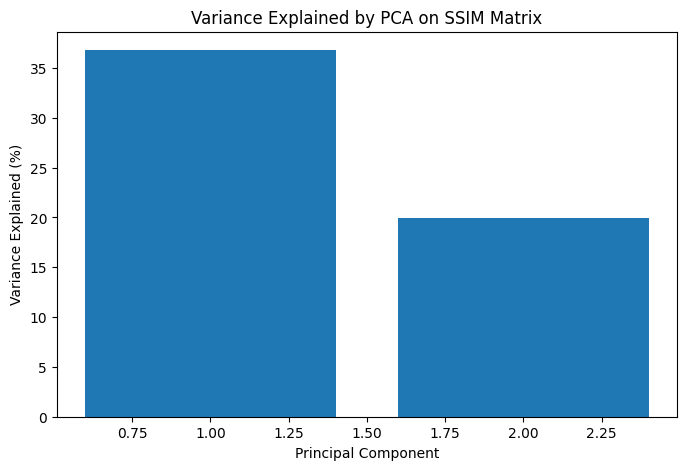

In [69]:
# Perform PCA on the SSIM matrix
pca = PCA(n_components=2)  # Adjust components as needed
pc_scores = pca.fit_transform(total_ssim)

# Variance explained by each principal component
explained_variance = pca.explained_variance_ratio_

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance * 100)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("Variance Explained by PCA on SSIM Matrix")
plt.show()

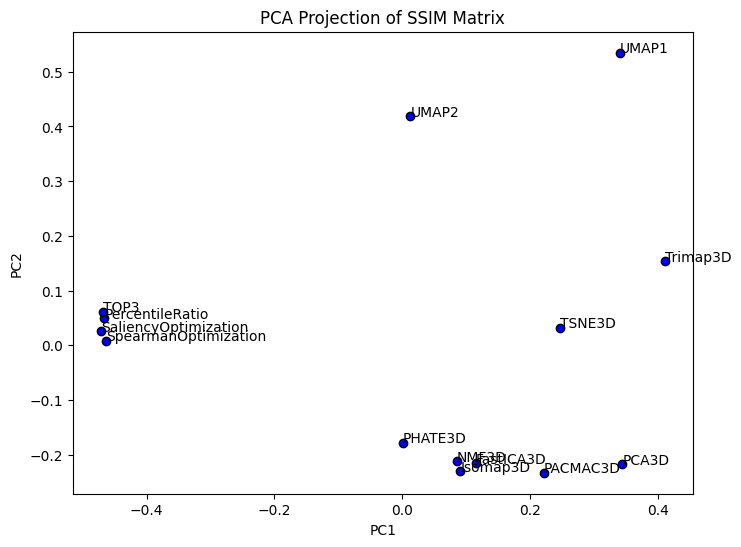

In [70]:
# Scatter plot of first two PCs
plt.figure(figsize=(8, 6))
plt.scatter(pc_scores[:, 0], pc_scores[:, 1], c="blue", edgecolors="black")

image_paths = [p.split("\\")[-1].split('.')[0].split('_')[1] for p in paths]
# Annotate points with image names
for i, img_name in enumerate(image_paths):
    plt.annotate(img_name, (pc_scores[i, 0], pc_scores[i, 1]))

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of SSIM Matrix")
plt.show()

In [46]:
info_gain

[0.5880932695355108,
 0.5047423972061866,
 0.43997089058679706,
 0.4074055611535502,
 0.4074055611535502,
 0.5499018766865413,
 0.6935628191536349,
 0.5437383163361016,
 0.5437383163361016,
 0.5499018766865413,
 0.5638925469897407,
 0.5638925469897407,
 0.43997089058679706,
 0.5207901710899494]